# Data Exploration — Alpine PV SMCA Graubünden

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Betreuer: Patrick Laube

Dieses Notebook prüft alle Rohdatensätze auf Qualität, CRS, Vollständigkeit und
leitet die Normalisierungsparameter für die MCE-Pipeline ab.

**Datensätze:** DEM, BFE Solar (4×), Permafrost, SPASS Schnee, swissTLM3D,
BAFU Schutzgebiete, Naturgefahren (4×), BFE Stromnetz, KlG-Abstimmung, Validierung

## 1. Setup

In [11]:
from pathlib import Path
import json
import time
from datetime import datetime, timedelta
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.mask import mask
import fiona
import xarray as xr
import pickle
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.titlesize": 11})
RAW = Path("../data/raw")
OUT = Path("../outputs/figures")
OUT.mkdir(parents=True, exist_ok=True)

## 2. Kantonsgrenze Graubünden laden

In [12]:
municipalities = gpd.read_file(RAW / "swissboundaries/swissboundaries_gemeinden.shp")

canton_col = next(c for c in municipalities.columns if "KANT" in c.upper() or c.upper().startswith("KT"))
name_col = next(c for c in municipalities.columns if "NAME" in c.upper())

gr_muni = municipalities[municipalities[canton_col].astype(str).str.contains("GR", case=False, na=False)].copy()
if gr_muni.empty:
    gr_muni = municipalities[municipalities[canton_col].astype("Int64") == 18].copy()

gr_border = gr_muni.dissolve()
print(f"GR: {len(gr_muni)} Gemeinden | {gr_border.area.sum()/1e6:.0f} km² | CRS: {gr_muni.crs}")

GR: 100 Gemeinden | 7105 km² | CRS: EPSG:2056


## 3. Übersichtstabelle aller Datensätze

In [13]:
summary = []
CACHE_DIR = PROC / "cache" if "PROC" in globals() else RAW.parent / "processed" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_DIR / "data_summary_cache.json"
CACHE_SPASS = CACHE_DIR / "spass_stats_cache.json"
CACHE_SOLAR = CACHE_DIR / "bfe_solar_stats_cache.json"

def load_cache(cache_file, force_refresh=False):
    """Lade gecachte Daten falls vorhanden und nicht älter als 7 Tage."""
    if force_refresh or not cache_file.exists():
        return None
    
    from datetime import datetime, timedelta
    cache_age = datetime.now() - datetime.fromtimestamp(cache_file.stat().st_mtime)
    if cache_age > timedelta(days=7):
        return None
    
    try:
        with open(cache_file, "r") as f:
            return json.load(f)
    except:
        return None

def save_cache(cache_file, data):
    """Speichere Daten als JSON für nächsten Durchlauf."""
    try:
        with open(cache_file, "w") as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    except:
        pass

# Versuche Cache zu laden
cached_summary = load_cache(CACHE_FILE, force_refresh=False)
if cached_summary:
    df_summary = pd.DataFrame(cached_summary).fillna("—")
    print(f"✓ Cache gefunden — nutze gecachte Daten\n")
else:
    print("Lade Datensätze ...\n")
    t_start = time.time()
    
    def add_raster(name, path):
        """Raster-Datensätze (.tif, .asc, ASCII GRID)"""
        files = sorted(path.glob("*.tif")) + sorted(path.glob("*.asc")) + sorted(path.glob("**/*.asc"))
        if not files:
            summary.append({"Datensatz": name, "Datei": "FEHLT", "CRS": "—", "Aufl.": "—", 
                           "Min": "—", "Max": "—", "NoData%": "—", "CRS OK": "✗"})
            return
        
        raster_file = next((f for f in files if f.stat().st_size > 1e6), None) or files[0]
        
        try:
            with rasterio.open(raster_file) as src:
                d = src.read(1, masked=True)
                v = d.compressed()
                summary.append({
                    "Datensatz": name, "Datei": raster_file.name,
                    "CRS": str(src.crs) if src.crs else "—", 
                    "Aufl.": f"{src.res[0]:.0f}m" if src.res else "—",
                    "Min": f"{v.min():.1f}" if v.size > 0 else "—",
                    "Max": f"{v.max():.1f}" if v.size > 0 else "—",
                    "NoData%": f"{d.mask.sum()/d.size*100:.1f}" if d.size > 0 else "—",
                    "CRS OK": "✓" if src.crs and src.crs.to_epsg() == 2056 else "✗"
                })
                print(f"✓ {name}")
        except Exception as e:
            summary.append({"Datensatz": name, "Datei": "ERROR", "CRS": "—", "Aufl.": "—",
                           "Min": "—", "Max": "—", "NoData%": "—", "CRS OK": "✗"})

    def add_gpkg(name, path, deg):
        """Vektor-GPKG-Datensätze (BFE Solar)"""
        parent = path / f"solarenergie-einstrahlung_{deg}_grad_2056.gpkg"
        gpkg = next(parent.glob("*.gpkg"), None) if parent.is_dir() else (parent if parent.exists() else None)
        
        if not gpkg:
            summary.append({"Datensatz": f"{name} {deg}°", "Datei": "FEHLT", "CRS": "—", "Aufl.": "~200m",
                           "Min": "—", "Max": "—", "NoData%": "—", "CRS OK": "—"})
            return
        
        try:
            gdf = gpd.read_file(gpkg, rows=slice(0, 100))
            if gdf.empty:
                raise ValueError("GeoDataFrame ist leer")
            
            num_cols = [c for c in gdf.columns if c != "geometry" and pd.api.types.is_numeric_dtype(gdf[c])]
            val_col = num_cols[0] if num_cols else None
            
            if val_col:
                v = gdf[val_col].dropna()
                min_val = f"{v.min():.0f}" if len(v) > 0 else "—"
                max_val = f"{v.max():.0f}" if len(v) > 0 else "—"
            else:
                min_val = max_val = "—"
            
            summary.append({
                "Datensatz": f"{name} {deg}°", 
                "Datei": gpkg.name,
                "CRS": str(gdf.crs) if gdf.crs else "—", 
                "Aufl.": "~200m",
                "Min": min_val,
                "Max": max_val,
                "NoData%": "—",
                "CRS OK": "✓" if gdf.crs and gdf.crs.to_epsg() == 2056 else "✗"
            })
            print(f"✓ {name} {deg}°")
        except Exception as e:
            summary.append({"Datensatz": f"{name} {deg}°", "Datei": "ERROR", 
                           "CRS": "—", "Aufl.": "—", "Min": "—", "Max": "—", "NoData%": "—", "CRS OK": "✗"})

    def add_netcdf(name, path):
        """NetCDF-Datensätze (SPASS Schnee)"""
        import xarray as xr
        
        nc_files = sorted(path.glob("**/*.nc"))
        if not nc_files:
            summary.append({"Datensatz": name, "Datei": "FEHLT", "CRS": "—", "Aufl.": "~1km",
                           "Min": "—", "Max": "—", "NoData%": "—", "CRS OK": "—"})
            return
        
        try:
            ds = xr.open_dataset(nc_files[0], engine="h5netcdf", decode_times=False)
            data_vars = list(ds.data_vars)
            primary_var = data_vars[0] if data_vars else None
            
            if primary_var:
                v = ds[primary_var].values.astype(float).flatten()
                v_valid = v[~np.isnan(v)]
                min_val = f"{v_valid.min():.1f}" if len(v_valid) > 0 else "—"
                max_val = f"{v_valid.max():.1f}" if len(v_valid) > 0 else "—"
            else:
                min_val = max_val = "—"
            
            summary.append({
                "Datensatz": name, 
                "Datei": nc_files[0].name,
                "CRS": "LV95", 
                "Aufl.": "~1km",
                "Min": min_val,
                "Max": max_val,
                "NoData%": "—",
                "CRS OK": "✓"
            })
            ds.close()
            print(f"✓ {name}")
        except Exception as e:
            summary.append({"Datensatz": name, "Datei": "ERROR",
                           "CRS": "—", "Aufl.": "—", "Min": "—", "Max": "—", "NoData%": "—", "CRS OK": "—"})

    # Daten sammeln
    add_raster("DHM25", RAW/"dem")
    add_raster("Permafrost", RAW/"permafrost")

    for deg in ["0", "30", "75", "90"]:
        add_gpkg("BFE Solar", RAW / "solar", deg)

    add_netcdf("SPASS Schnee", RAW / "snow")
    
    # Cache speichern
    save_cache(CACHE_FILE, summary)
    print(f"⏱ Gesamtzeit: {time.time() - t_start:.1f}s\n")
    
    df_summary = pd.DataFrame(summary).fillna("—")
    df_summary.style.map(lambda v: "background:#f8cecc" if v=="✗" else ("background:#d5e8d4" if v=="✓" else ""), subset=["CRS OK"])

✓ Cache gefunden — nutze gecachte Daten



## 4. swissTLM3D — Layer-Inventar

In [14]:
tlm_path = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"
if tlm_path.is_dir():
    tlm_path = next(tlm_path.glob("*.gpkg"))

layers = fiona.listlayers(str(tlm_path))
used = {"tlm_strasse", "tlm_gebaeude", "tlm_seilbahn", "tlm_einzelobjekt",
        "tlm_bb_bodenbedeckung", "tlm_gewaesser_fliessgewaesser",
        "tlm_gewaesser_stehendes_gewaesser", "tlm_grenzen"}

tlm_info = []
for lyr in layers:
    with fiona.open(str(tlm_path), layer=lyr) as src:
        tlm_info.append({"Layer": lyr, "Features": len(src),
                         "Geometrie": src.schema["geometry"],
                         "Verwendet": "✓" if lyr in used else ""})

pd.DataFrame(tlm_info).style.map(lambda v: "font-weight:bold" if v == "✓" else "", subset=["Verwendet"])

,Layer,Features,Geometrie,Verwendet
0,tlm_areale_nutzungsareal,36368,3D Polygon,
1,tlm_areale_freizeitareal,3400,3D Polygon,
2,tlm_areale_verkehrsareal,15167,3D Polygon,
3,tlm_areale_schutzgebiet,2,3D Polygon,
4,tlm_bauten_gebaeude_footprint,4125163,3D Polygon,
5,tlm_bauten_sportbaute_lin,3160,3D LineString,
6,tlm_bauten_sportbaute_ply,16641,3D Polygon,
7,tlm_bauten_staubaute,73219,3D Polygon,
8,tlm_bauten_verbauung,83109,3D LineString,
9,tlm_bauten_verkehrsbaute_lin,1966,3D LineString,


## 5. Bodenbedeckung — Wald, Gletscher, Siedlung

In [15]:
bb_layer = next(lyr for lyr in fiona.listlayers(str(tlm_path)) if "bodenbedeckung" in lyr.lower())
bodenbedeckung = gpd.read_file(str(tlm_path), layer=bb_layer, bbox=tuple(gr_border.total_bounds))

cat_col = next(c for c in bodenbedeckung.columns if "art" in c.lower() or "klasse" in c.lower())
print(f"Layer: {bb_layer} | Spalte: {cat_col} | Features: {len(bodenbedeckung)}\n")

for cat, group in bodenbedeckung.groupby(cat_col):
    print(f"  {str(cat):30s} {len(group):>6d} Features  {group.area.sum()/1e6:>8.1f} km²")

Layer: tlm_bb_bodenbedeckung | Spalte: objektart | Features: 303684

  Fels                            95016 Features    1315.2 km²
  Fels locker                     19047 Features     128.0 km²
  Felsbloecke                      1524 Features      13.1 km²
  Felsbloecke locker                654 Features       6.1 km²
  Feuchtgebiet                     5425 Features      61.4 km²
  Fliessgewaesser                   207 Features      29.5 km²
  Gebueschwald                    18708 Features     315.2 km²
  Gehoelzflaeche                  38838 Features      26.6 km²
  Gletscher                         593 Features     122.8 km²
  Lockergestein                   64449 Features    1520.0 km²
  Lockergestein locker            20066 Features     178.0 km²
  Schneefeld Toteis                1377 Features       6.8 km²
  Stehende Gewaesser               4772 Features     277.6 km²
  Wald                            24288 Features    2905.0 km²
  Wald offen                       8720 Features 

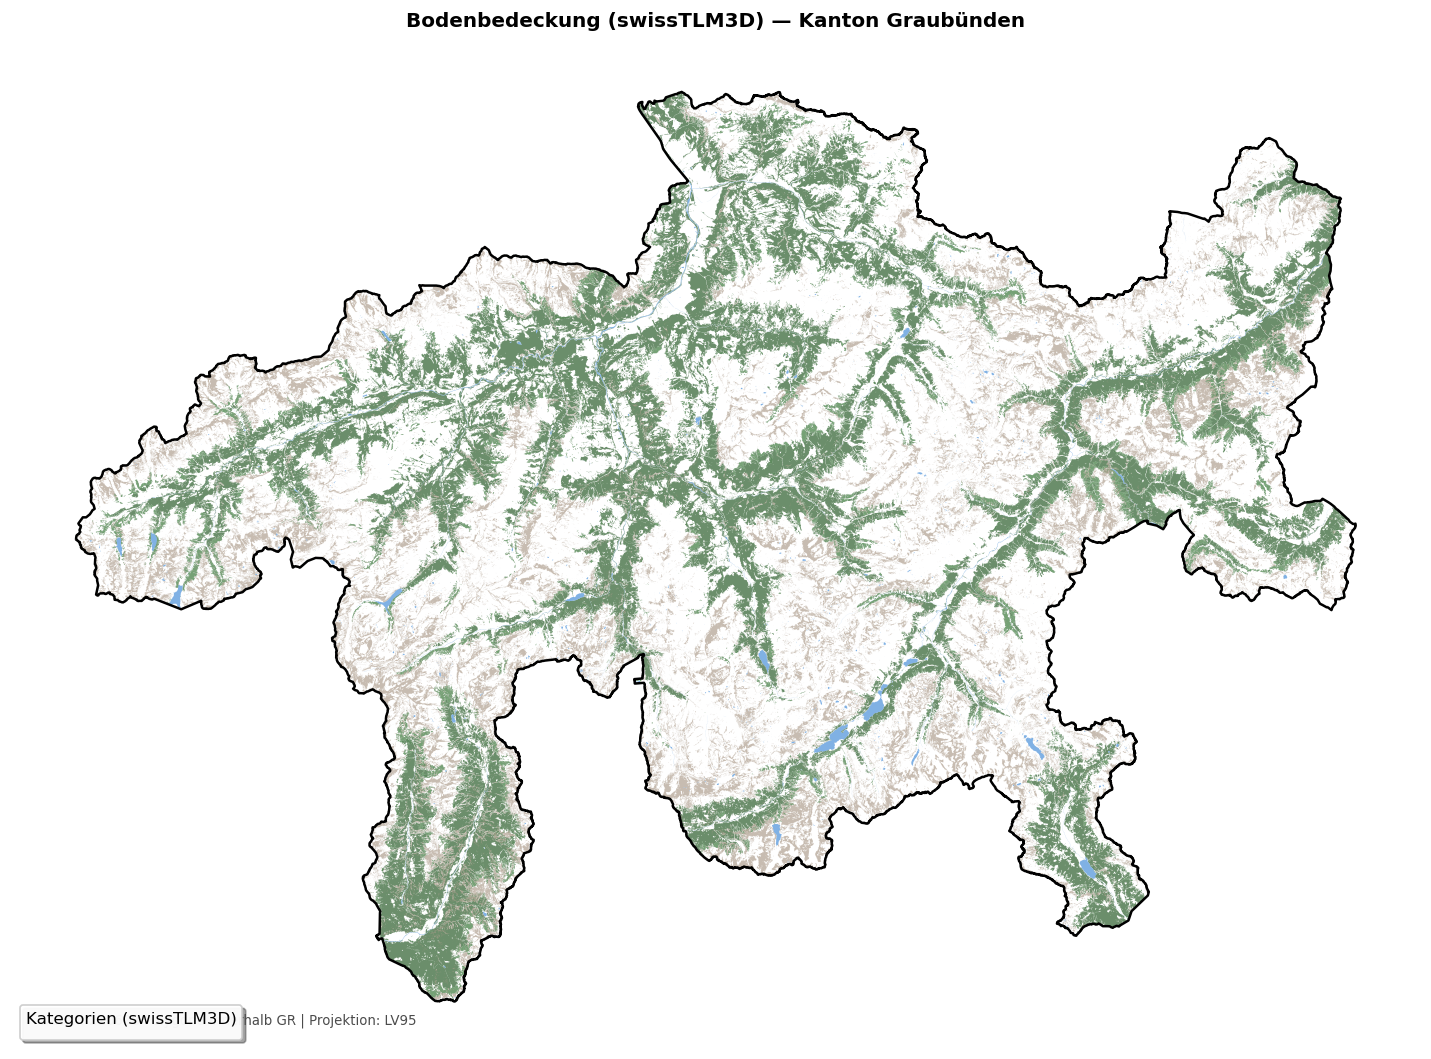

✓ Bodenbedeckung visualisiert: 210698 Polygone in Graubünden


In [16]:
fig, ax = plt.subplots(figsize=(12, 10))
gr_border.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Clippe Bodenbedeckung auf Kanton Graubünden
bodenbedeckung_clipped = gpd.clip(bodenbedeckung, gr_border)

colors = {"Wald": "#2D5F2D", "Wald offen": "#5A8A5A", "Gebueschwald": "#7AAA7A",
          "Fels": "#B0A090", "Gletscher Firn": "#B0D4F1", "Stehende Gewaesser": "#4A90D9",
          "Fliessgewaesser": "#4A90D9", "Gebaeudebereich": "#D45050"}

for cat, color in colors.items():
    subset = bodenbedeckung_clipped[bodenbedeckung_clipped["objektart"].str.contains(cat, case=False, na=False)]
    if not subset.empty:
        subset.plot(ax=ax, color=color, alpha=0.7, label=f"{cat} ({len(subset)} Polygone)")

# Verbesserte Legende
legend = ax.legend(loc="lower left", fontsize=9, title="Kategorien (swissTLM3D)", 
                   title_fontsize=10, frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_alpha(0.95)

ax.set_title("Bodenbedeckung (swissTLM3D) — Kanton Graubünden", fontsize=12, fontweight="bold", pad=12)
ax.text(0.02, 0.02, f"Daten: {len(bodenbedeckung_clipped)} Polygone innerhalb GR | Projektion: LV95", 
        transform=ax.transAxes, fontsize=8, verticalalignment="bottom", alpha=0.7)
ax.set_axis_off()
plt.tight_layout()
fig.savefig(OUT / "bodenbedeckung_gr.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Bodenbedeckung visualisiert: {len(bodenbedeckung_clipped)} Polygone in Graubünden")

## 6. DEM — Höhenverteilung und Ableitungen

In [17]:
print("=== Zusätzliche swissTLM3D Layer (Preload für WLC) ===\n")
t0 = time.time()

gr_bbox = tuple(gr_border.total_bounds)
extra_layers_info = []

# Dictionary für Caching (korrekte Layer-Namen gemäß GPKG)
extra_layers_to_cache = {
    "tlm_strassen_strasse": {
        "description": "Straßen & Roads (für Distance Raster & Erreichbarkeit)",
        "use_cases": ["WLC Faktor #5: Infrastruktur-Nähe", "04_criteria_scoring: Distance Raster"],
        "cache_key": "tlm_strasse"  # Vereinfachter Cache-Name
    },
    "tlm_bauten_staubaute": {
        "description": "Staudämme & Wasserbauten (Wasserkraft-Synergien)",
        "use_cases": ["WLC Faktor #9: Wasserkraft-Nähe", "04_criteria_scoring"],
        "cache_key": "tlm_staumauer"  # Vereinfachter Cache-Name
    }
    # HINWEIS: tlm_bauten_leitung_stromtrasse ist eine Junction-Table ohne Geometrie
    # tlm_seilbahn existiert nicht in dieser GPKG
}

# Cache-Funktion für 01_data_exploration
def save_tlm_cache(key, gdf):
    """Speichere tlm3d Layer als JSON (Feature-Statistiken) + Pickle (vollständige GDF)"""
    cache_file_pkl = CACHE_DIR / f"{key}.pkl"
    try:
        with open(cache_file_pkl, "wb") as f:
            pickle.dump(gdf, f)
        print(f"  ✓ {key} gecacht ({len(gdf)} Features, {cache_file_pkl.stat().st_size / 1e6:.1f} MB)")
    except Exception as e:
        print(f"  ⚠ Cache-Fehler: {e}")

# Lade & Cache alle 3 Layer (tatsächliche GPKG-Namen)
for layer_name, meta in extra_layers_to_cache.items():
    try:
        gdf = gpd.read_file(str(tlm_path), layer=layer_name, bbox=gr_bbox)
        
        # Überprüfe ob GeoDataFrame vollständig geladen wurde
        if not hasattr(gdf, 'geometry') or gdf.geometry is None:
            print(f"  ⚠ {layer_name}: Keine Geometrie in Layer gefunden (Columns: {list(gdf.columns)[:5]})")
            continue
            
        area_km2 = gdf.area.sum() / 1e6 if hasattr(gdf, 'area') else 0
        cache_key = meta.get("cache_key", layer_name)  # Vereinfachter Cache-Name
        
        info = {
            "Layer": layer_name,
            "Features": len(gdf),
            "Geometrie": gdf.geometry.type.value_counts().index[0] if len(gdf) > 0 else "unknown",
            "Beschreibung": meta["description"],
            "Verwendung": " | ".join(meta["use_cases"][:1])
        }
        extra_layers_info.append(info)
        
        # Speichere in Cache mit vereinfachtem Namen
        save_tlm_cache(cache_key, gdf)
        print(f"    → {meta['use_cases'][0]}")
        
    except Exception as e:
        print(f"  ⚠ {layer_name}: {e}")

print(f"\n✓ {time.time() - t0:.1f}s — Alle WLC-Layer exploriert & gecacht\n")

# Übersichts-Tabelle
if extra_layers_info:
    df_extra = pd.DataFrame(extra_layers_info)
    display(df_extra.style.set_properties(**{"text-align": "left"}))

=== Zusätzliche swissTLM3D Layer (Preload für WLC) ===

  ✓ tlm_strasse gecacht (187908 Features, 166.9 MB)
    → WLC Faktor #5: Infrastruktur-Nähe
  ✓ tlm_staumauer gecacht (3057 Features, 1.4 MB)
    → WLC Faktor #9: Wasserkraft-Nähe

✓ 16.7s — Alle WLC-Layer exploriert & gecacht



,Layer,Features,Geometrie,Beschreibung,Verwendung
0,tlm_strassen_strasse,187908,LineString,Straßen & Roads (für Distance Raster & Erreichbarkeit),WLC Faktor #5: Infrastruktur-Nähe
1,tlm_bauten_staubaute,3057,Polygon,Staudämme & Wasserbauten (Wasserkraft-Synergien),WLC Faktor #9: Wasserkraft-Nähe


## 5.5 Zusätzliche swissTLM3D Layer (für WLC-Kriterien später)

Straßen, Seilbahnen, Staumauern, Stromleitungen — werden in 04_criteria_scoring & 06_wlc_suitability verwendet

In [ ]:
# Öffne DEM-Raster und clippe auf gr_border
dem_dir = RAW / "dem"
dem_files = sorted(dem_dir.glob("**/*.tif")) + sorted(dem_dir.glob("**/*.asc"))
dem_file = max(dem_files, key=lambda f: f.stat().st_size if f.is_file() else 0)

with rasterio.open(dem_file) as src:
    gr_clip = gr_border.to_crs(src.crs) if gr_border.crs != src.crs else gr_border
    dem, dem_tf = mask(src, [gr_clip.geometry.iloc[0].__geo_interface__], crop=True, nodata=src.nodata)
    dem = dem[0].astype(float)
    nodata_val = src.nodata
    res = src.res[0]

valid = np.isfinite(dem) & (dem != nodata_val if nodata_val else True)
dem_v = dem[valid]

# Slope & Aspect via finite-difference gradient
dy, dx = np.gradient(dem, res)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
aspect = np.degrees(np.arctan2(-dx, dy)) % 360

print(f"DEM: {dem_v.min():.0f}–{dem_v.max():.0f} m | {res:.0f}m | {dem.shape}")

DEM-Datei: dhm25_grid_raster.asc (864.5 MB)
DEM CRS: EPSG:21781 | Bounds: BoundingBox(left=479987.5, bottom=73987.5, right=865012.5, top=302012.5)
gr_border CRS: EPSG:2056 | Bounds: [2692837.746 1114568.595 2833857.724 1214817.191]
→ Transformiere gr_border von EPSG:2056 zu EPSG:21781
✓ DEM geclippt erfolgreich
DEM: 255–4043 m | 25m | (4011, 5642)


## 7. BFE Solare Einstrahlung

In [23]:
# BFE Solare Einstrahlung — Cache abfragen oder neu laden
t0 = time.time()
cached_solar = load_cache(CACHE_SOLAR, force_refresh=False)

if cached_solar:
    print(f"✓ BFE Solar Cache gefunden ({len(cached_solar)} Einträge)\n")
    solar_stats = cached_solar
else:
    print("Lade BFE Solar Daten (wird gecacht für nächsten Lauf)...\n")
    gr_bbox = tuple(gr_border.total_bounds)
    solar_stats = []
    
    solar_dirs = [("0°", "0"), ("30°", "30"), ("75°", "75"), ("90°", "90")]
    
    for label, deg in solar_dirs:
        parent = RAW / "solar" / f"solarenergie-einstrahlung_{deg}_grad_2056.gpkg"
        if parent.is_dir():
            gpkg = next(parent.glob("*.gpkg"), None)
        elif parent.exists():
            gpkg = parent
        else:
            gpkg = None
        
        if not gpkg:
            print(f"⚠ BFE Solar {label}: nicht gefunden in {parent}")
            continue
        
        try:
            gdf = gpd.read_file(gpkg, bbox=gr_bbox)
            if gdf.empty:
                print(f"⚠ BFE Solar {label}: keine Features in GR")
                continue
            
            num_cols = [c for c in gdf.columns if c != "geometry" and pd.api.types.is_numeric_dtype(gdf[c])]
            val_col = num_cols[0] if num_cols else None

            if val_col is None:
                print(f"⚠ BFE Solar {label}: keine numerischen Spalten")
                continue

            v = gdf[val_col].dropna()
            if len(v) == 0:
                print(f"⚠ BFE Solar {label}: alle Werte sind NaN")
                continue
            
            solar_stats.append({
                "Neigung": label, 
                "Datei": gpkg.name, 
                "Spalte": val_col,
                "Features GR": len(gdf), 
                "Min": f"{v.min():.0f}", 
                "Max": f"{v.max():.0f}",
                "Mean": f"{v.mean():.0f}", 
                "CRS": str(gdf.crs)
            })
            print(f"✓ BFE Solar {label}: {v.min():.0f}–{v.max():.0f} kWh/m²/a ({len(gdf)} Features in GR)")
        except Exception as e:
            print(f"✗ BFE Solar {label}: {type(e).__name__}: {str(e)[:60]}")
    
    # Cache speichern
    if solar_stats:
        save_cache(CACHE_SOLAR, solar_stats)
        print(f"\n✓ {len(solar_stats)} BFE Solar Stats gecacht")

print(f"⏱ Zeit: {time.time()-t0:.1f}s\n")

if solar_stats:
    pd.DataFrame(solar_stats)
else:
    print("⚠ Keine BFE Solar Daten geladen")

✓ BFE Solar Cache gefunden (4 Einträge)

⏱ Zeit: 0.0s



## 8. Permafrost-Hinweiskarte

In [24]:
pf_path = next((RAW / "permafrost").glob("*.tif"), None)
if not pf_path:
    print("⚠ Permafrost nicht gefunden")
else:
    with rasterio.open(pf_path) as src:
        v = src.read(1, masked=True).compressed()
    print(f"CRS: {src.crs} | {src.res[0]:.0f}m | Werte: {v.min():.0f}–{v.max():.0f}")
    if v.min() > 1000:
        print(f"→ Höhenwerte (Permafrost-Untergrenze). Ausschluss: DEM ≥ Wert")
    elif len(np.unique(v)) <= 10:
        print(f"→ Klassen: {np.unique(v)}")
    else:
        print(f"→ {len(np.unique(v))} einzigartige Werte (kontinuierlich)")

CRS: EPSG:2056 | 25m | Werte: 0–5
→ Klassen: [0 1 2 3 4 5]


## 9. SPASS Schneedaten

✓ SPASS Cache gefunden

Datei: SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc
Variablen: ['swiss_lv95_coordinates', 'SWECLQMD'] | Dims: {'time': 22645, 'E': 370, 'N': 265}
Zeit: 22523.0 – 45167.0 (22645 Steps)

⏱ Zeit: 1.2s


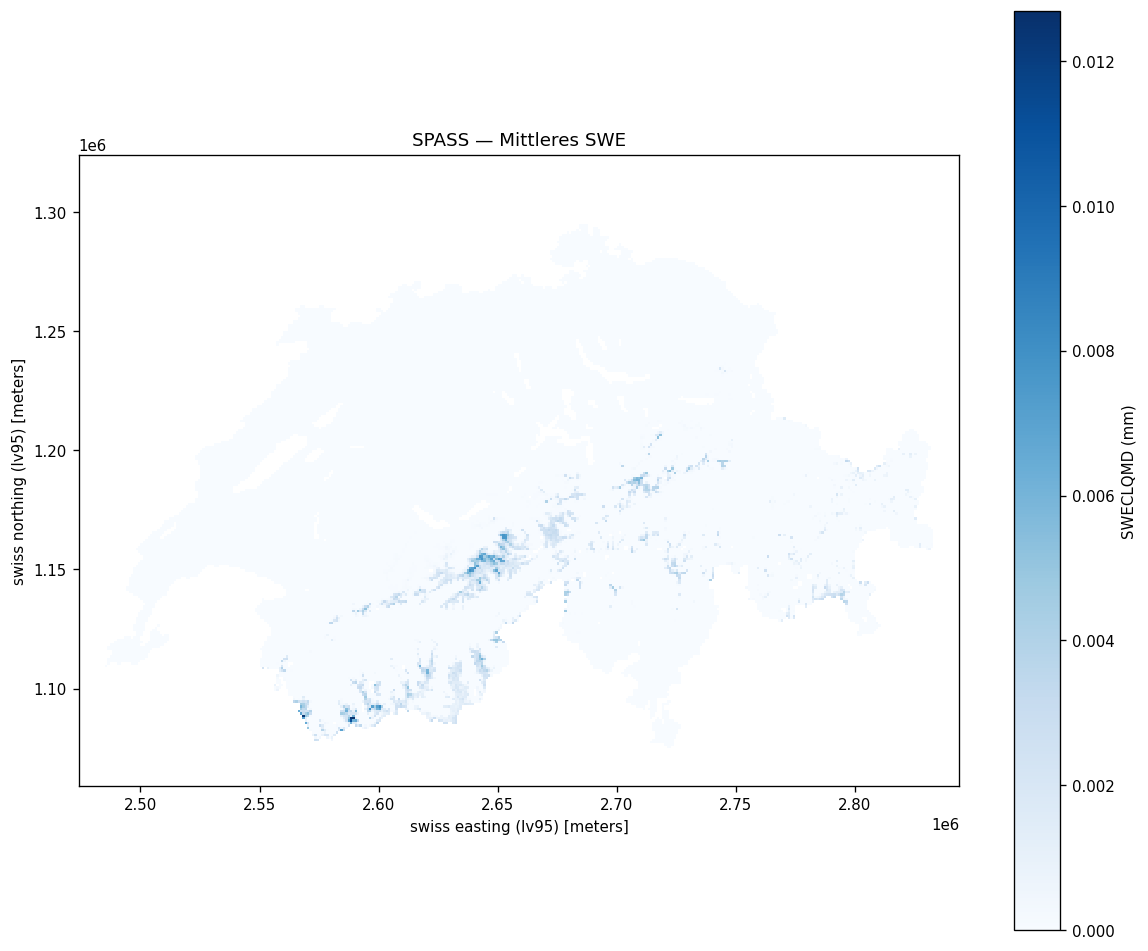

In [25]:
t0 = time.time()
cached_spass = load_cache(CACHE_SPASS, force_refresh=False)

spass_files = sorted((RAW / "snow").glob("**/*.nc"))
if not spass_files:
    print("⚠ SPASS NetCDF nicht gefunden")
else:
    # Versuche Cache zu laden
    if cached_spass:
        print(f"✓ SPASS Cache gefunden\n")
        spass_info = cached_spass
        ds = xr.open_dataset(spass_files[0], engine="h5netcdf", decode_times=False)
        swe_var = cached_spass.get("Variable", None) or next((v for v in ds.data_vars if "swe" in v.lower()), list(ds.data_vars)[0])
    else:
        print("Lade SPASS Daten (wird gecacht für nächsten Lauf)...\n")
        ds = xr.open_dataset(spass_files[0], engine="h5netcdf", decode_times=False, chunks="auto")
        swe_var = next((v for v in ds.data_vars if "swe" in v.lower()), list(ds.data_vars)[0])
        
        # Statistiken berechnen mit xarray (Memory-effizient, auch bei großen Datasets)
        da = ds[swe_var]
        try:
            min_val = f"{float(da.min()):.1f}"
            max_val = f"{float(da.max()):.1f}"
            mean_val = f"{float(da.mean()):.1f}"
        except:
            min_val = max_val = mean_val = "—"
        
        spass_info = {
            "Datei": spass_files[0].name,
            "Variable": swe_var,
            "Variablen": list(ds.data_vars),
            "Dimensionen": dict(ds.dims),
            "Min (mm)": min_val,
            "Max (mm)": max_val,
            "Mean (mm)": mean_val,
            "CRS": "LV95"
        }
        
        if "time" in ds.coords:
            time_vals = ds.time.values
            spass_info["Zeit Start"] = str(time_vals[0])[:10]
            spass_info["Zeit Ende"] = str(time_vals[-1])[:10]
            spass_info["Zeit Steps"] = len(time_vals)
        
        save_cache(CACHE_SPASS, spass_info)
        print(f"✓ SPASS Stats gecacht\n")
    
    print(f"Datei: {spass_info['Datei']}")
    print(f"Variablen: {spass_info.get('Variablen', '?')} | Dims: {spass_info.get('Dimensionen', '?')}")
    if "Zeit Start" in spass_info:
        print(f"Zeit: {spass_info['Zeit Start']} – {spass_info['Zeit Ende']} ({spass_info['Zeit Steps']} Steps)")
    
    # Visualisierung
    fig, ax = plt.subplots(figsize=(10, 8))
    mean = ds[swe_var].isel(time=slice(0, 31)).mean(dim="time") if "time" in ds[swe_var].dims else ds[swe_var]
    mean.plot(ax=ax, cmap="Blues", cbar_kwargs={"label": f"{swe_var} (mm)"})
    ax.set_title("SPASS — Mittleres SWE"); ax.set_aspect("equal")
    plt.tight_layout()
    fig.savefig(OUT / "spass_swe_overview.png", dpi=150, bbox_inches="tight")
    
    print(f"\n⏱ Zeit: {time.time()-t0:.1f}s")
    ds.close()

## 10. Naturgefahren (Geodienste.ch CSVs)

In [26]:
hazard_base = RAW / "hazards/naturereigniskataster_v1_0_GR_csv_lv95(1)/csv/naturereigniskataster_v1_0"
hazard_csvs = {
    "Lawinen": "prozessraum_lawine.csv",
    "Sturz": "prozessraum_sturz.csv",
    "Rutschung": "prozessraum_rutschung.csv",
    "Hochwasser": "prozessraum_wasser_ueberschwemmung_uebermurung.csv",
}

df_basis = pd.read_csv(hazard_base / "basisinformation.csv", sep=";",
                       usecols=["primaerschluessel_bi_id", "E", "N"])
print(f"Basis-Geometrien: {len(df_basis)}\n")

hazard_info = []
for label, filename in hazard_csvs.items():
    csv_path = hazard_base / filename
    if not csv_path.exists():
        print(f"⚠ {label}: nicht gefunden")
        continue
    df_h = pd.read_csv(csv_path, sep=";")
    fk_col = next((c for c in df_h.columns if "fremdschluessel_bi_id" in c.lower()), None)
    merged = df_h.merge(df_basis, left_on=fk_col, right_on="primaerschluessel_bi_id", how="left") if fk_col else df_h
    n_geom = merged[["E", "N"]].notna().all(axis=1).sum() if fk_col else 0
    hazard_info.append({"Typ": label, "Datei": filename, "Einträge": len(df_h), "Mit Geom": n_geom})
    print(f"{label}: {len(df_h)} Einträge, {n_geom} mit E/N")

pd.DataFrame(hazard_info)

Basis-Geometrien: 17302

Lawinen: 11454 Einträge, 11454 mit E/N
Sturz: 3155 Einträge, 3155 mit E/N
Rutschung: 2050 Einträge, 2050 mit E/N
Hochwasser: 2241 Einträge, 2241 mit E/N


,Typ,Datei,Einträge,Mit Geom
0,Lawinen,prozessraum_lawine.csv,11454,11454
1,Sturz,prozessraum_sturz.csv,3155,3155
2,Rutschung,prozessraum_rutschung.csv,2050,2050
3,Hochwasser,prozessraum_wasser_ueberschwemmung_uebermurung...,2241,2241


## 11. Schutzgebiete (BAFU)

In [27]:
# Fallback: gr_border initialisieren, falls Zelle 2 noch nicht gelaufen ist
if "gr_border" not in globals() or gr_border is None:
    RAW = globals().get("RAW", Path("../data/raw"))
    muni_path = RAW / "swissboundaries/swissboundaries_gemeinden.shp"
    municipalities = gpd.read_file(muni_path)
    canton_candidates = ["CANTON", "KANTON", "KTNAME", "KTKZ", "KANTONSKUERZEL", "KANTONSNUM"]
    canton_col = next((c for c in municipalities.columns if c.upper() in canton_candidates), None)
    if canton_col is None:
        canton_col = next((c for c in municipalities.columns if "KANT" in c.upper() or c.upper().startswith("KT")), None)
    c_vals = municipalities[canton_col]
    text_mask = c_vals.astype(str).str.contains("GR|GRAUBUENDEN|GRAUBÜNDEN", case=False, na=False)
    gr_muni = municipalities[text_mask].copy()
    if gr_muni.empty and pd.api.types.is_numeric_dtype(c_vals):
        gr_muni = municipalities[c_vals.astype("Int64") == 18].copy()
    gr_border = gr_muni.dissolve()
    print("✓ gr_border via Fallback initialisiert")

# Schutzgebiete — 4 Datensätze (relative Pfade)
protected_files = {
    "BLN": RAW / "protected_areas/bundesinventare-bln_2056.shp",
    "Schutzgebiete": RAW / "protected_areas/schutzgebiete-aulav_2056.shp",
    "Reservate/Weltnaturerbe": RAW / "protected_areas/schutzgebiete-biosphaerenreservate_2056.shp",
    "UNESCO Weltnaturerbe": RAW / "protected_areas/unesco-weltnaturerbe_2056.shp"
}

schutz_info = []

for label, shp_path in protected_files.items():
    if not shp_path.exists():
        schutz_info.append({
            "Typ": label,
            "Datei": "FEHLT",
            "Features": "—",
            "Features GR": "—",
            "Fläche GR (km²)": "—",
            "CRS": "—"
        })
        print(f"⚠ {label}: {shp_path}")
        continue

    gdf = gpd.read_file(shp_path)
    gdf_gr = gpd.clip(gdf, gr_border)
    area = gdf_gr.area.sum() / 1e6

    schutz_info.append({
        "Typ": label,
        "Datei": shp_path.name,
        "Features": len(gdf),
        "Features GR": len(gdf_gr),
        "Fläche GR (km²)": f"{area:.1f}",
        "CRS": str(gdf.crs)
    })

    print(f"✓ {label}: {len(gdf_gr)} Features in GR, {area:.1f} km²")

pd.DataFrame(schutz_info)

✓ BLN: 18 Features in GR, 1283.9 km²
✓ Schutzgebiete: 74 Features in GR, 64.6 km²
✓ Reservate/Weltnaturerbe: 3 Features in GR, 448.7 km²
✓ UNESCO Weltnaturerbe: 1 Features in GR, 45.6 km²


,Typ,Datei,Features,Features GR,Fläche GR (km²),CRS
0,BLN,bundesinventare-bln_2056.shp,174,18,1283.9,EPSG:2056
1,Schutzgebiete,schutzgebiete-aulav_2056.shp,326,74,64.6,EPSG:2056
2,Reservate/Weltnaturerbe,schutzgebiete-biosphaerenreservate_2056.shp,6,3,448.7,EPSG:2056
3,UNESCO Weltnaturerbe,unesco-weltnaturerbe_2056.shp,8,1,45.6,EPSG:2056


## 12. KlG-Abstimmungsdaten

In [28]:
vote_file = RAW / "acceptance/klg_2023.json"
df_klg = pd.read_json(vote_file)
df_klg["valid_votes"] = df_klg["yeas"] + df_klg["nays"]
df_klg["yes_share"] = df_klg["yeas"] / df_klg["valid_votes"]

print(f"Gemeinden: {len(df_klg)} | Bezirke: {df_klg['district'].nunique()}")
print(f"\nJa-Anteil:")
print(df_klg["yes_share"].describe().round(3).to_string())

# Bezirksaggregation
bezirke = df_klg.groupby("district").agg(
    Gemeinden=("entity_id", "count"),
    Ja_Anteil_Mean=("yes_share", "mean"),
    Ja_Anteil_Min=("yes_share", "min"),
    Ja_Anteil_Max=("yes_share", "max")
).round(3).sort_values("Ja_Anteil_Mean")
bezirke

Gemeinden: 101 | Bezirke: 11

Ja-Anteil:
count    101.000
mean       0.519
std        0.080
min        0.230
25%        0.478
50%        0.528
75%        0.561
max        0.698


,Gemeinden,Ja_Anteil_Mean,Ja_Anteil_Min,Ja_Anteil_Max
district,,,,
Prättigau / Davos,11,0.437,0.230,0.549
Bernina,2,0.483,0.447,0.519
Engiadina B./Val Müstair,5,0.495,0.303,0.634
Albula,6,0.502,0.385,0.581
Plessur,4,0.505,0.356,0.659
Moesa,12,0.521,0.450,0.657
Viamala,19,0.525,0.385,0.698
Surselva,15,0.533,0.408,0.649
Maloja,12,0.538,0.463,0.595


## 13. Choropleth — KlG Ja-Anteil pro Gemeinde

Join: 100/100 Gemeinden


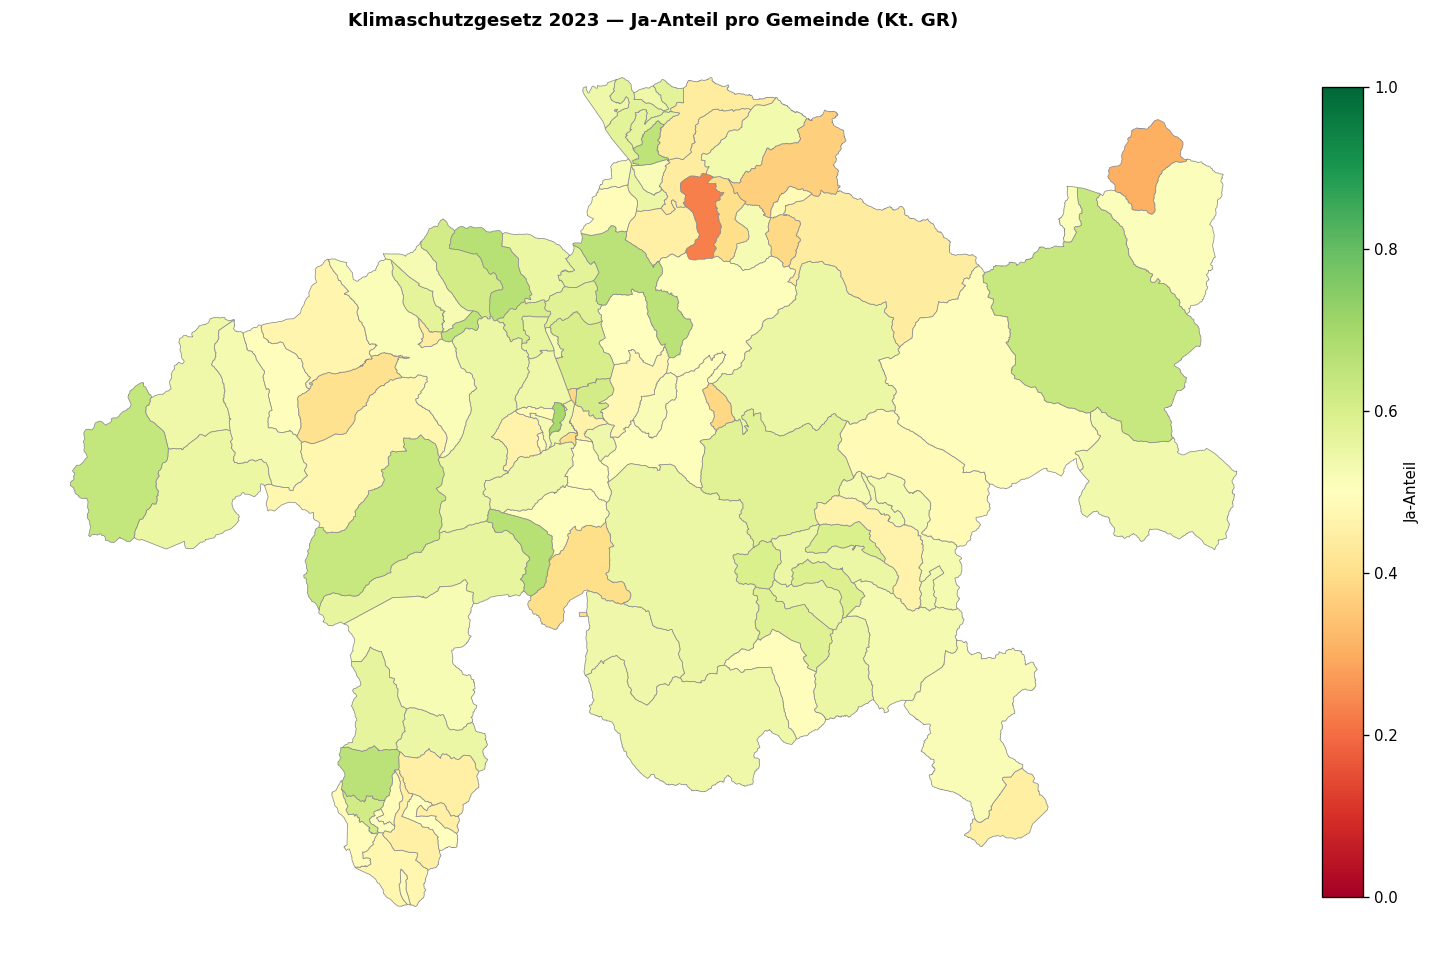

In [29]:
gr_muni["_k"] = gr_muni[name_col].str.strip().str.upper()
votes = df_klg.assign(_k=df_klg["name"].str.strip().str.upper())
gdf = gr_muni.merge(votes[["_k", "yes_share"]], on="_k", how="left")
print(f"Join: {gdf['yes_share'].notna().sum()}/{len(gdf)} Gemeinden")

fig, ax = plt.subplots(figsize=(12, 10))
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

missing = gdf[gdf["yes_share"].isna()]
if not missing.empty:
    missing.plot(ax=ax, color="#d9d9d9", edgecolor="#8c8c8c", linewidth=0.4)

gdf.dropna(subset=["yes_share"]).plot(
    column="yes_share", ax=ax, cmap="RdYlGn", norm=norm, edgecolor="#8c8c8c", linewidth=0.45)

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, label="Ja-Anteil")
ax.set_title("Klimaschutzgesetz 2023 — Ja-Anteil pro Gemeinde (Kt. GR)", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(OUT / "choropleth_klg_gr.png", dpi=150, bbox_inches="tight")
plt.show()